In [157]:
import numpy as np
from pymdp.agent import Agent

import matplotlib
matplotlib.use('Agg')
import matplotlib.pyplot as plt
import io
import imageio
from itertools import product
import random
from IPython.display import Image, display

# reproducibility
random.seed(44352)
np.random.seed(4531)

In [158]:
# Build arena mask + mappings
# Change rows, cols, and corridor params below to create different arenas.

def make_two_rooms_with_corridor(rows=3, left_cols=2, corridor_cols=3, right_cols=2,
                                 corridor_rows=(1),
                                 prefer_total_cols=None):
    
    default_total = left_cols + corridor_cols + right_cols
    if prefer_total_cols is None:
        total_cols = default_total
    else:
        total_cols = prefer_total_cols

    mask = np.zeros((rows, total_cols), dtype=bool)


    left_start = 0
    left_end = left_start + left_cols
    mask[:, left_start:left_end] = True

    corridor_start = left_end
    corridor_end = corridor_start + corridor_cols
    if corridor_end > total_cols:
        raise ValueError("Corridor doesn't fit in prefer_total_cols; increase total width or reduce corridor width.")
    for r in corridor_rows:
        mask[r, corridor_start:corridor_end] = True


    right_end = total_cols
    right_start = right_end - right_cols
    mask[:, right_start:right_end] = True

    return mask, {"left": (slice(None), slice(left_start, left_end)),
                  "corridor": (slice(None), slice(corridor_start, corridor_end)),
                  "right": (slice(None), slice(right_start, right_end))}

# "T" maze with the perpendicular arm on the right
rows = 4
left_cols = 0
corridor_cols = 3   # corridor width
right_cols = 2
corridor_rows = (1,2)  # allow rows 1 and 2 (middle two rows), top(0) and bottom(3) are blocked in corridor
mask, regions = make_two_rooms_with_corridor(rows=rows, left_cols=left_cols,
                                             corridor_cols=corridor_cols, right_cols=right_cols,
                                             corridor_rows=corridor_rows, prefer_total_cols=None)

print("Arena mask shape:", mask.shape)
print("Passable cells count:", mask.sum())


Arena mask shape: (4, 5)
Passable cells count: 14


In [159]:
# Helpers/setup


rows, cols = mask.shape
# create list of valid (r,c) and mapping arrays
valid_rc = [(r, c) for r in range(rows) for c in range(cols) if mask[r, c]]
n_states = len(valid_rc)


# observation modalities -> threat intensity/dist, shelter, agent location
n_threat_obs = 4                         # intensities 0..3 with higher intensity is closer => can make this modular in the future
n_shelter_obs = 2 # [NOT AT, AT]
n_agent_obs = n_states

actions = ["up", "down", "left", "right", "stay"]
n_actions = len(actions)

# maps: rc -> compact state id (0..n_states-1), and state->(r,c)
rc_to_state = -np.ones((rows, cols), dtype=int)   # -1 for blocked cells
state_to_rc = [None] * n_states
for i, (r, c) in enumerate(valid_rc):
    rc_to_state[r, c] = i
    state_to_rc[i] = (r, c)

def state_idx_to_rc(idx):
    return state_to_rc[int(idx)]

def rc_to_state_idx(r, c):
    return int(rc_to_state[r, c])

print("n_states (valid cells):", n_states)
print("Sample mapping: first 6 states -> rc:", state_to_rc[:6])

def step_from_state(state_idx, action):
    r, c = state_idx_to_rc(state_idx)
    if action == 0:   # up
        nr, nc = r - 1, c
    elif action == 1: # down
        nr, nc = r + 1, c
    elif action == 2: # left
        nr, nc = r, c - 1
    elif action == 3: # right
        nr, nc = r, c + 1
    elif action == 4: # stay
        nr, nc = r, c
    else:
        raise ValueError("bad action")

    # If target is outside bounds or blocked, stay in place
    if nr < 0 or nr >= rows or nc < 0 or nc >= cols:
        return state_idx
    if not mask[nr, nc]:
        return state_idx
    return rc_to_state_idx(nr, nc)

# Example sanity checks
for i in range(min(6, n_states)):
    r,c = state_idx_to_rc(i)
    print("state", i, "rc", (r,c), "neighbors:", [step_from_state(i,a) for a in range(len(actions))])

# compute manhattan distance using rc positions since no diagonal moves allowed
def manhattan_states(s1, s2):
    r1, c1 = state_idx_to_rc(s1)
    r2, c2 = state_idx_to_rc(s2)
    return abs(r1 - r2) + abs(c1 - c2)


n_states (valid cells): 14
Sample mapping: first 6 states -> rc: [(0, 3), (0, 4), (1, 0), (1, 1), (1, 2), (1, 3)]
state 0 rc (0, 3) neighbors: [0, 5, 0, 1, 0]
state 1 rc (0, 4) neighbors: [1, 6, 0, 1, 1]
state 2 rc (1, 0) neighbors: [2, 7, 2, 3, 2]
state 3 rc (1, 1) neighbors: [3, 8, 2, 4, 3]
state 4 rc (1, 2) neighbors: [4, 9, 3, 5, 4]
state 5 rc (1, 3) neighbors: [0, 10, 4, 6, 5]


In [160]:
# Build B transition matrix

n_agent = n_states
n_threat = n_states
n_shelter = n_states

n_controls_agent = n_actions
n_controls_threat = 1
n_controls_shelter = 1

# build B_agent: shape (S_next, S_current, n_controls_agent)
B_agent = np.zeros((n_agent, n_agent, n_controls_agent), dtype=float)

for s in range(n_agent):
    for a in range(n_actions):
        ns = step_from_state(s, a)
        # make deterministic-ish with tiny exploration noise
        B_agent[ns, s, a] += 0.99 # [next_state, state, action]
        # distribute small noise among other reachable neighbors (including stay)
        # find reachable neighbors from s
        neighbors = set(step_from_state(s, aa) for aa in range(n_actions))
        neighbors = sorted(neighbors)
        # distribute 0.01 equally (excluding ns since we already gave 0.99)
        residue = 0.01
        for nb in neighbors:
            if nb == ns:
                continue
            B_agent[nb, s, a] += residue / max(1, (len(neighbors)-1))

# normalize columns for numerical safety
for a in range(n_controls_agent):
    col_sums = B_agent[:, :, a].sum(axis=0)
    for s in range(n_agent):
        if col_sums[s] <= 0:
            B_agent[:, s, a] = 1.0 / n_agent
        else:
            B_agent[:, s, a] /= col_sums[s]

# B for static threat and shelter (identity)
B_threat = np.zeros((n_threat, n_threat, n_controls_threat))
for s in range(n_threat):
    B_threat[s, s, 0] = 1.0

B_shelter = np.zeros((n_shelter, n_shelter, n_controls_shelter))
for s in range(n_shelter):
    B_shelter[s, s, 0] = 1.0

B = np.empty(3, dtype=object)
B[0] = B_agent
B[1] = B_threat
B[2] = B_shelter

print("Built B with shapes:")
print(" B_agent:", B_agent.shape, "n_states:", n_agent)


Built B with shapes:
 B_agent: (14, 14, 5) n_states: 14


In [161]:
# Build A state-observation map likelihoods

# observation sizes
n_threat_obs = 4
n_shelter_obs = 5
n_agent_obs = n_agent

A_threat = np.zeros((n_threat_obs, n_agent, n_threat, n_shelter))
for a in range(n_agent):
    for t in range(n_threat):
        for s in range(n_shelter):
            d = manhattan_states(a, t)
            if d == 0:
                A_threat[3, a, t, s] = 1.0
                # A_threat[2, a, t, s] = 0.25
            elif d == 1:
                A_threat[2, a, t, s] = 0.75
                A_threat[1, a, t, s] = 0.25
            elif d == 2:
                A_threat[1, a, t, s] = 0.75
                A_threat[0, a, t, s] = 0.25
            else:
                A_threat[0, a, t, s] = 1.0
A_threat /= A_threat.sum(axis=0, keepdims=True)

# shelter modality (is agent at shelter index?)
A_shelter = np.zeros((n_shelter_obs, n_agent, n_threat, n_shelter))
for a in range(n_agent):
    for t in range(n_threat):
        for s in range(n_shelter):
            d = manhattan_states(a, s)
            if d == 0:
                A_shelter[4, a, t, s] = 1.0
            elif d == 1:
                A_shelter[3, a, t, s] = 0.8
                A_shelter[2, a, t, s] = 0.2
            elif d == 2:
                A_shelter[2, a, t, s] = 0.95
                A_shelter[1, a, t, s] = 0.05
            elif d == 3:
                A_shelter[1, a, t, s] = 1.0
            else:
                A_shelter[0, a, t, s] = 1.0
A_shelter /= A_shelter.sum(axis=0, keepdims=True)

# agent self-location
A_agent = np.zeros((n_agent_obs, n_agent, n_threat, n_shelter))
for a in range(n_agent):
    A_agent[a, a, :, :] = 1.0
    # small uniform noise for others
    # A_agent[:, a, :, :] += (0.05 / (n_agent_obs - 1))
A_agent /= A_agent.sum(axis=0, keepdims=True)

# pack into object array
A = np.empty(3, dtype=object)
A[0] = A_threat
A[1] = A_shelter
A[2] = A_agent

print("Built A with shapes:", [A[i].shape for i in range(3)])


Built A with shapes: [(4, 14, 14, 14), (5, 14, 14, 14), (14, 14, 14, 14)]


In [162]:
# D priors — agent & threat location probabilities spread over whole arena (no idea), shelter known

# helper: collect valid states in a column index
def collect_states_in_column(col_idx):
    states = []
    for r in range(rows):
        if 0 <= col_idx < cols and mask[r, col_idx]:
            states.append(rc_to_state_idx(r, col_idx))
    return sorted(states)

# find columns that contain any passable cells
cols_with_passable = np.where(mask.any(axis=0))[0]
if cols_with_passable.size == 0:
    raise RuntimeError("Arena mask has no passable cells.")

leftmost_col = int(cols_with_passable.min())
rightmost_col = int(cols_with_passable.max())

# collect states in leftmost and rightmost columns
leftcol_states = collect_states_in_column(leftmost_col)
rightcol_states = collect_states_in_column(rightmost_col)

print(f"Leftmost column index: {leftmost_col}, states count: {len(leftcol_states)}")
print(f"Rightmost column index: {rightmost_col}, states count: {len(rightcol_states)}")


D_agent = np.ones(n_agent, dtype=float) / float(n_agent)
D_threat = np.ones(n_threat, dtype=float) / float(n_threat)


D_shelter = np.zeros(n_shelter, dtype=float)
if len(leftcol_states) > 0:
    D_shelter[leftcol_states] = 1.0 / len(leftcol_states)


# pack into object array for pymdp
D = np.empty(3, dtype=object)
D[0] = D_agent
D[1] = D_threat
D[2] = D_shelter

print("D shapes:", [D[i].shape for i in range(3)])
print("Agent prior sum:", D_agent.sum(), "Threat prior sum:", D_threat.sum(),
      "Shelter-prior mass on leftcol:", D_shelter.sum())


Leftmost column index: 0, states count: 2
Rightmost column index: 4, states count: 4
D shapes: [(14,), (14,), (14,)]
Agent prior sum: 0.9999999999999998 Threat prior sum: 0.9999999999999998 Shelter-prior mass on leftcol: 1.0


In [163]:
# helper - visualization renderer

def render_grid_frame_arena(agent_state, threat_state, shelter_state, visited_states, step,
                            threat_posterior=None, cell_size=48,
                            high_level_mode=None, current_scale=None, high_posterior=None,
                            high_step=None):
    """
    Draw arena with a colored status strip above it.
    The strip background color is GREEN when mode is safe, RED when danger.
    All strip text is white for readability.

    Args:
      - high_level_mode: optional string like "SAFE" or "DANGER" (preferred).
      - current_scale: optional tuple (threat_scale, shelter_scale).
      - high_posterior: optional vector [p_safe, p_danger] or scalar p_danger.
      - high_step: optional integer (high-level timestep) to show alongside low-level step.
    """
    from PIL import Image, ImageDraw, ImageFont
    import numpy as np

    # normalize shelter_state
    if isinstance(shelter_state, (list, tuple, np.ndarray, set)):
        shelter_set = set(int(x) for x in shelter_state)
    else:
        shelter_set = {int(shelter_state)}

    W = cols * cell_size
    H = rows * cell_size

    # --- draw grid ---
    img_grid = Image.new('RGB', (W, H), (255,255,255))
    draw = ImageDraw.Draw(img_grid)

    for r in range(rows):
        for c in range(cols):
            x0, y0 = c * cell_size, r * cell_size
            x1, y1 = x0 + cell_size - 1, y0 + cell_size - 1
            if not mask[r, c]:
                fill = (50,50,50)
            else:
                idx = rc_to_state_idx(r, c)
                if idx in visited_states and idx not in shelter_set and idx != agent_state and idx != threat_state:
                    fill = (220,220,220)
                else:
                    fill = (255,255,255)
            draw.rectangle([x0, y0, x1, y1], fill=fill, outline=(0,0,0))

    # heatmap overlay (if provided)
    if threat_posterior is not None:
        heat = np.zeros((rows, cols))
        for s_idx in range(len(threat_posterior)):
            r,c = state_idx_to_rc(s_idx)
            heat[r,c] = float(threat_posterior[s_idx])
        for r in range(rows):
            for c in range(cols):
                if mask[r, c] and heat[r,c] > 0:
                    alpha = min(0.9, heat[r,c]*2.5)
                    overlay = Image.new('RGBA', (cell_size, cell_size), (255,0,0,int(alpha*200)))
                    img_grid.paste(overlay, (c*cell_size, r*cell_size), overlay)

    # shelters
    for s_idx in shelter_set:
        r, c = state_idx_to_rc(s_idx)
        draw.rectangle([c*cell_size, r*cell_size, (c+1)*cell_size-1, (r+1)*cell_size-1],
                       fill=(150,255,150), outline=(0,0,0))

    # threat
    if threat_state is not None:
        r, c = state_idx_to_rc(int(threat_state))
        draw.rectangle([c*cell_size, r*cell_size, (c+1)*cell_size-1, (r+1)*cell_size-1],
                       fill=(255,150,150), outline=(0,0,0), width=2)
        try:
            draw.text((c*cell_size+cell_size//3, r*cell_size+cell_size//4), "T", fill=(0,0,0))
        except Exception:
            pass

    # agent
    if agent_state is not None:
        r, c = state_idx_to_rc(int(agent_state))
        draw.rectangle([c*cell_size, r*cell_size, (c+1)*cell_size-1, (r+1)*cell_size-1],
                       fill=(30,30,200), outline=(0,0,0), width=2)
        try:
            draw.text((c*cell_size+cell_size//3, r*cell_size+cell_size//4), "A", fill=(255,255,255))
        except Exception:
            pass

    # Top status strip (single color: green for safe, red for danger)
    strip_h = max(46, cell_size // 2)
    final_H = H + strip_h
    final_img = Image.new('RGB', (W, final_H), (255,255,255))
    draw_final = ImageDraw.Draw(final_img)

    # font
    try:
        font = ImageFont.truetype("DejaVuSans.ttf", 12)
    except Exception:
        font = ImageFont.load_default()

    # Decide mode color:
    # Priority: use high_level_mode string if provided; else use high_posterior (p_danger threshold 0.5); default SAFE.
    mode_is_danger = False
    if high_level_mode is not None:
        try:
            mm = str(high_level_mode).lower()
            mode_is_danger = ('danger' in mm) or ('panic' in mm) or ('alert' in mm)
        except Exception:
            mode_is_danger = False
    elif high_posterior is not None:
        try:
            hp = np.array(high_posterior).ravel()
            p_d = float(hp[1]) if hp.size > 1 else float(hp[0])
            mode_is_danger = (p_d > 0.5)
        except Exception:
            mode_is_danger = False
    else:
        mode_is_danger = False

    strip_color = (180, 30, 30) if mode_is_danger else (30, 160, 50)  # red-ish or green-ish
    draw_final.rectangle([0, 0, W, strip_h], fill=strip_color)

    # White text for visibility
    text_color = (255,255,255)
    pad_x = 12
    y_text = (strip_h - 16) // 2

    # Left text: Step low (high)
    if high_step is None:
        left_text = f"Step: {int(step)}"
    else:
        left_text = f"Step: {int(step)} ({int(high_step)})"
    draw_final.text((pad_x, y_text), left_text, fill=text_color, font=font)

    # # Mode text (slightly right)
    # mode_text = f"Mode: {str(high_level_mode) if high_level_mode is not None else ('DANGER' if mode_is_danger else 'SAFE')}"
    # draw_final.text((pad_x + 220, y_text), mode_text, fill=text_color, font=font)

    # # Scale text (center area)
    # if current_scale is None:
    #     scale_text = "Scale: N/A"
    # else:
    #     try:
    #         s0, s1 = current_scale
    #         scale_text = f"Scale: ({s0:.2f}, {s1:.2f})"
    #     except Exception:
    #         scale_text = f"Scale: {current_scale}"
    # draw_final.text((pad_x + 420, y_text), scale_text, fill=text_color, font=font)

    # # P(danger) numeric (right side)
    # if high_posterior is not None:
    #     try:
    #         hp = np.array(high_posterior).ravel()
    #         p_d = float(hp[1]) if hp.size > 1 else float(hp[0])
    #         pd_text = f"P(danger): {p_d:.2f}"
    #     except Exception:
    #         pd_text = "P(danger): N/A"
    # else:
    #     pd_text = "P(danger): N/A"
    # # right align near the right edge
    # try:
    #     tw, th = font.getsize(pd_text)
    # except Exception:
    #     tw, th = (len(pd_text)*7, 12)
    # draw_final.text((W - pad_x - tw, y_text), pd_text, fill=text_color, font=font)

    # Paste the grid under the strip
    final_img.paste(img_grid, (0, strip_h))

    return np.array(final_img)



In [164]:
def softmax(x):
    ex = np.exp(x - np.max(x))
    return ex / ex.sum()

# threat_obs outcomes: [none, far, near, at] -> negative increases with closeness
U_threat = np.array([-0.10, -0.10, -0.2, -0.2])  # more negative -> avoid
U_threat *= 0.8
C_threat = np.log(softmax(U_threat))
# shelter
U_shelter = np.array([-0.1, 0.1, 0.15, 0.20, 0.5]) # positive for being in shelter
U_shelter *= 0.5
C_shelter = np.log(softmax(U_shelter))
# agent self-location: no utility, keep zeros
U_agent = np.zeros(n_agent_obs)
C_agent = np.log(softmax(U_agent))


# make C arrays of shape (n_outcomes, T) - here broadcast across T
T = policy_len = 1
C = [C_threat[:,None].repeat(T,axis=1),
     C_shelter[:,None].repeat(T,axis=1),
     C_agent[:,None].repeat(T,axis=1)]

print(f"C (log pref): {C}")

# Convert C (list of arrays shape (n_outcomes, T)) to object array with one entry per modality
C_obj = np.empty(3, dtype=object)
C_obj[0] = C[0]   # threat modality log-pref (shape (4,T))
C_obj[1] = C[1]   # shelter modality log-pref (shape (2,T))
C_obj[2] = C[2]   # agent proprio (shape (9,T))

C = C_obj

D_obj = np.empty(3, dtype=object)
D_obj[0] = D_agent
D_obj[1] = D_threat
D_obj[2] = D_shelter

D = D_obj

print("C and D converted to object-arrays for pymdp.")
print("C shapes:", [C[i].shape for i in range(len(C))])
print("D shapes:", [D[i].shape for i in range(len(D))])


C (log pref): [array([[-1.34709415],
       [-1.34709415],
       [-1.42709415],
       [-1.42709415]]), array([[-1.74920202],
       [-1.64920202],
       [-1.62420202],
       [-1.59920202],
       [-1.44920202]]), array([[-2.63905733],
       [-2.63905733],
       [-2.63905733],
       [-2.63905733],
       [-2.63905733],
       [-2.63905733],
       [-2.63905733],
       [-2.63905733],
       [-2.63905733],
       [-2.63905733],
       [-2.63905733],
       [-2.63905733],
       [-2.63905733],
       [-2.63905733]])]
C and D converted to object-arrays for pymdp.
C shapes: [(4, 1), (5, 1), (14, 1)]
D shapes: [(14,), (14,), (14,)]


In [ ]:
# Generate all possible policies
# n_control_factors = number of hidden-state factors = 3 (agent, threat dummy, shelter dummy)
n_control_factors = 3
num_controls = [n_controls_agent, n_controls_threat, n_controls_shelter]  # [5,1,1] (includes 1 control => nothing)

def generate_policies(n_actions, n_control_factors, policy_len):
    policies = []
    for seq in product(range(n_actions), repeat=policy_len):
        pol = np.zeros((policy_len, n_control_factors), dtype=int)
        pol[:, 0] = seq   # agent control
        # other factors remain zeros (no control)
        policies.append(pol)
    return policies # (policy_len, n_control_factors),

policies = generate_policies(n_actions, n_control_factors, policy_len)
n_policies = len(policies)

print(f"Generated {n_policies} policies (h={policy_len}, n_actions={n_actions}).")
print("policy[0] shape:", policies[0].shape)

Generated 5 policies (h=1, n_actions=5).
policy[0] shape: (1, 3)


In [166]:
# Generative process (environment) class
class world_env():
    def __init__(self, true_agent_pos = (1, 0), true_threat_pos = rightcol_states[0], true_shelter_pos = np.array(leftcol_states, dtype = int)):
        self.starting_pos = rc_to_state_idx(true_agent_pos[0], true_agent_pos[1])
        self.agent_pos = self.starting_pos
        self.threat_pos = true_threat_pos
        self.shelter_pos = true_shelter_pos
        print(f'--- INIT --- Agent postion: {state_idx_to_rc(self.starting_pos)}, Threat position: {state_idx_to_rc(self.threat_pos)}')

    def step(self, action):
        new_state_idx = step_from_state(self.agent_pos, action)
        self.agent_pos = new_state_idx
        agent_obs = self.agent_pos

        d_a_t = manhattan_states(self.agent_pos, self.threat_pos)
        threat_obs = max(3 - d_a_t, 0)

        d_a_s = 1000 # np.inf
        for s_pos in self.shelter_pos:
            d_a_si = manhattan_states(self.agent_pos, s_pos)
            if (d_a_si < d_a_s):
                d_a_s = d_a_si
        shelter_obs = max(4 - d_a_s, 0)

        return agent_obs, threat_obs, shelter_obs
    
    def start(self):
        self.agent_pos = self.starting_pos
        agent_obs, threat_obs, shelter_obs = self.step(4) # stay
        return agent_obs, threat_obs, shelter_obs

In [167]:
# Create the low-level pymdp Agent (movement controller)
# control facets: [n_actions, 1, 1]
l1_agent = Agent(
    A = A,
    B = B,
    C = C,
    D = D,
    # E = E,
    policy_len = policy_len,
    num_controls = [n_controls_agent, n_controls_threat, n_controls_shelter],
    control_fac_idx = [0],   # only the agent factor is controllable
    gamma = 4.0,
    alpha = 8.0,
    action_selection='stochastic',
    use_utility = True,
    use_states_info_gain = True
)

print("Agent constructed.")


Agent constructed.


In [168]:
# Create high-level pydmp agent (danger/safety context)

n_danger = 2
n_obs_high = 2   # observed danger: 0/1 no/yes

# A observation model (likelihood): P(obs | danger)
p_correct = 0.99
A_high = np.zeros((n_obs_high, n_danger), dtype=float)
A_high[1, 1] = p_correct
A_high[0, 1] = 1 - p_correct
A_high[0, 0] = p_correct
A_high[1, 0] = 1 - p_correct
A_high_obj = np.empty(1, dtype=object); A_high_obj[0] = A_high

# Controls and mapping -> now controls have real causal effect in the high-level model
# control 0 = no-scale, control 1 = apply-scale (aims to push system toward safe)
control_scales = {
    0: (1.0, 1.0),   # no scaling (threat_scale, shelter_scale)
    1: (5.0, 5.0),   # danger scaling: stronger negative utility for threat (but we model causal effect below)
}
n_controls_high = len(control_scales)

# Build B_high transition model with shape (S_next, S_current, n_controls_high)
# B_high[s_next, s_current, c] = P(s_next | s_current, control=c)
B_high = np.zeros((n_danger, n_danger, n_controls_high), dtype=float)

# Control 0: identity (no intervention)
for s in range(n_danger):
    B_high[s, s, 0] = 1.0

# Control 1: intervention that tends to move the system to SAFE in the next step
#  P(next=safe | current=safe, control=1)   = 0.99
#  P(next=danger | current=safe, control=1) = 0.01
#  P(next=safe | current=danger, control=1) = 0.95
#  P(next=danger | current=danger, control=1) = 0.05
B_high[0, 0, 1] = 0.99   # safe -> safe
B_high[1, 0, 1] = 0.01
B_high[0, 1, 1] = 0.95   # danger -> safe (intervention helps resolve danger)
B_high[1, 1, 1] = 0.05

B_high_obj = np.empty(1, dtype=object)
B_high_obj[0] = B_high

# D_high prior (uniform)
D_high = np.array([0.5, 0.5], dtype=float)
D_high_obj = np.empty(1, dtype=object); D_high_obj[0] = D_high

# C_high prefer safe
T_high = 1
U_high = np.array([10.0, 0.05])
C_high_vec = np.log(softmax(U_high))
# shape (n_obs_high, T_high), using T_high=1
C_high = C_high_vec[:, None].repeat(T_high, axis=1)
C_high_obj = np.empty(1, dtype=object); C_high_obj[0] = C_high

# High-level agent action helper - scale low-level C from base
U_threat_base = U_threat.copy()
U_shelter_base = U_shelter.copy()
U_agent_base = U_agent.copy()

def build_scaled_C(scale):
    if isinstance(scale, dict):
        threat_s = float(scale.get('threat', 1.0))
        shelter_s = float(scale.get('shelter', 1.0))
    elif isinstance(scale, (tuple, list, np.ndarray)):
        threat_s = float(scale[0])
        shelter_s = float(scale[1])
    else:
        # scalar
        threat_s = shelter_s = float(scale)

    # scale base utilities
    U_threat_scaled = np.array(U_threat_base, dtype=float) * threat_s
    U_shelter_scaled = np.array(U_shelter_base, dtype=float) * shelter_s
    U_agent_scaled = np.array(U_agent_base, dtype=float).copy()

    # convert to log-preferences for each modality (softmax -> log)
    # policy_len is expected to be defined in your namespace
    C_th = np.log(softmax(U_threat_scaled))[:, None].repeat(policy_len, axis=1)
    C_sh = np.log(softmax(U_shelter_scaled))[:, None].repeat(policy_len, axis=1)
    C_ag = np.log(softmax(U_agent_scaled))[:, None].repeat(policy_len, axis=1)

    C_obj_new = np.empty(3, dtype=object)
    C_obj_new[0] = C_th
    C_obj_new[1] = C_sh
    C_obj_new[2] = C_ag
    return C_obj_new

l2_agent = Agent(
    A = A_high_obj,
    B = B_high_obj,
    C = C_high_obj,
    D = D_high_obj,
    policy_len = 1,
    num_controls = [n_controls_high],
    control_fac_idx = [0],    # the only hidden factor is also controllable
    gamma = 8.0,
    alpha = 8.0,
    use_utility = True,          # allow it to use preferences
    use_states_info_gain = False  # allow EFE-driven choice
)

print("High-level controller (policy-based) constructed with controls:", list(control_scales.items()))

High-level controller (policy-based) constructed with controls: [(0, (1.0, 1.0)), (1, (5.0, 5.0))]


In [ ]:
from pymdp.control import calc_expected_utility, calc_states_info_gain 

world = world_env()

MAX_STEPS = 100

agent_obs, threat_obs, shelter_obs = world.start()

obs = [threat_obs, shelter_obs, agent_obs]

actions = ["Up", "Down", "Left", "Right", "Stay"]

visited = {world.starting_pos}

l1_forgetting_rate = 0.2
def decay_qs(ps, fr):
    qs = np.asarray(ps, dtype=float)
    n_elements = len(qs)
    uniform = np.ones(n_elements)/n_elements
    decayed = (1-fr)*qs + fr*uniform
    decayed /= decayed.sum()
    return decayed

danger_detection_threshold = 0.3
K_high = 16
t_high = K_high
cooldown = 12
current_scale = (1.0, 1.0)
scale_name = 'SAFE'

def fmt_topk_posterior(q_vec, k=3):
    q = np.asarray(q_vec, dtype=float)
    idx = np.argsort(q)[-k:][::-1]
    return [(int(i), float(q[i]), state_idx_to_rc(int(i))) for i in idx]

history = {'agent_loc': [], 'beliefs': [], 'util': [],  'info_gain': [], 'neg_efe': [], 'action': []}
l2_history = {}

frames = []


x=0
for t in range(MAX_STEPS):

    l1_qs = l1_agent.infer_states(obs)    
    l1_qpi, l1_G = l1_agent.infer_policies()
    l1_action = l1_agent.sample_action()[0]
    current_state = world.agent_pos
    next_state = step_from_state(current_state, l1_action)
    visited.add(next_state)

    agent_obs, threat_obs, shelter_obs = world.step(l1_action)
    obs = [threat_obs, shelter_obs, agent_obs]

    q_agent = np.array(l1_qs[0], dtype=float)
    q_threat = np.array(l1_qs[1], dtype=float)

    # L2 observation
    p_agent_at_threat = float(np.dot(q_agent, q_threat))
    l2_obs = 1 if (p_agent_at_threat > danger_detection_threshold) else 0

    if (t_high == 0) or (l2_obs == 1):
        # l2_obs = 1
        l2_qs = l2_agent.infer_states([l2_obs])
        l2_qpi, l2_G = l2_agent.infer_policies()
        l2_action = int(l2_agent.sample_action()[0]) # 0 = safe, 1 = danger

        print(f'obs={l2_obs}, act={l2_action}')
        scale_name = 'SAFE' if (l2_action == 0) else 'DANGER'

        updated_scale = control_scales[l2_action]
        
        if updated_scale == current_scale:
            print(f"t={t} | L2 maintains {scale_name} scale")
        else:
            print(f"t={t} | L2 changed to {scale_name} scale")
            l1_agent.C = build_scaled_C(updated_scale)

        # l2_history['action'].append(f't={t}, {scale_name}')

        current_scale = updated_scale
        if t_high == 0:
            t_high += K_high
        else:
            print(f't={t} in danger')
            t_high += cooldown + 1

    t_high -= 1

    decayed_qs = np.array([l1_qs[0], decay_qs(l1_qs[1], l1_forgetting_rate), l1_qs[2]], dtype=object) # HOW TO FORGET??
    l1_agent.reset(init_qs=decayed_qs)

    frame_img = render_grid_frame_arena(world.agent_pos, world.threat_pos, world.shelter_pos, visited, t,
                                   threat_posterior=l1_qs[1],
                                   high_level_mode=scale_name,
                                   cell_size=48)
    
    frames.append(frame_img)

    history['agent_loc'].append(state_idx_to_rc(current_state))
    history['beliefs'].append(fmt_topk_posterior(l1_qs[1]))
    history['neg_efe'].append(l1_G)
    history['action'].append(actions[int(l1_action)])
    history['util'].append()
    history['info_gain'].append()


print(f'Simulation finished, appended to history {x} times')




--- INIT --- Agent postion: (1, 0), Threat position: (0, 4)
obs=0, act=0
t=16 | L2 maintains SAFE scale
obs=0, act=0
t=32 | L2 maintains SAFE scale
obs=0, act=0
t=48 | L2 maintains SAFE scale
obs=0, act=0
t=64 | L2 maintains SAFE scale
obs=0, act=0
t=80 | L2 maintains SAFE scale
obs=0, act=0
t=96 | L2 maintains SAFE scale
Simulation finished, appended to history 0 times


Saved redo.gif


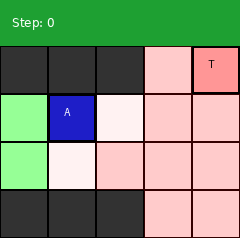

In [170]:
# Visualize & safe gif 
gif_path = "redo.gif"
imageio.mimsave(gif_path, frames, fps=10)
print(f"Saved {gif_path}")
display(Image(gif_path))

In [171]:
from pymdp.maths import softmax, softmax_obj_arr, spm_dot, spm_wnorm, spm_MDP_G, spm_log_single, kl_div, entropy, spm_cross
from pymdp import utils
import copy

for i in range(MAX_STEPS):
    print(f't = {i}')
    for j in history.keys():
        if j != 'l2_action':
            print(f'{j}: {history[j][i]}')
            if j == 'neg_efe':
                print(f'Most likely: {actions[int(np.argmax(history[j][i]))]}')
        print()

t = 0
agent_loc: (1, 0)

beliefs: [(13, 0.10526315789473684, (3, 4)), (12, 0.10526315789473684, (3, 3)), (11, 0.10526315789473684, (2, 4))]



IndexError: list index out of range

In [ ]:
def calc_expected_utility(qo_pi, C):
    """
    Computes the expected utility of a policy, using the observation distribution expected under that policy and a prior preference vector.

    Parameters
    ----------
    qo_pi: ``list`` of ``numpy.ndarray`` of dtype object
        Predictive posterior beliefs over observations expected under the policy, where ``qo_pi[t]`` stores the beliefs about
        observations expected under the policy at time ``t``
    C: ``numpy.ndarray`` of dtype object
       Prior over observations or 'prior preferences', storing the "value" of each outcome in terms of relative log probabilities. 
       This is softmaxed to form a proper probability distribution before being used to compute the expected utility.

    Returns
    -------
    expected_util: float
        Utility (reward) expected under the policy in question
    """
    n_steps = len(qo_pi)
    
    # initialise expected utility
    expected_util = 0

    # loop over time points and modalities
    num_modalities = len(C)

    # reformat C to be tiled across timesteps, if it's not already
    modalities_to_tile = [modality_i for modality_i in range(num_modalities) if C[modality_i].ndim == 1]

    # make a deepcopy of C where it has been tiled across timesteps
    C_tiled = copy.deepcopy(C)
    for modality in modalities_to_tile:
        C_tiled[modality] = np.tile(C[modality][:,None], (1, n_steps) )
    
    C_prob = softmax_obj_arr(C_tiled) # convert relative log probabilities into proper probability distribution

    for t in range(n_steps):
        for modality in range(num_modalities):

            lnC = spm_log_single(C_prob[modality][:, t])
            expected_util += qo_pi[t][modality].dot(lnC)

    return expected_util


def calc_states_info_gain(A, qs_pi):
    """
    Computes the Bayesian surprise or information gain about states of a policy, 
    using the observation model and the hidden state distribution expected under that policy.

    Parameters
    ----------
    A: ``numpy.ndarray`` of dtype object
        Sensory likelihood mapping or 'observation model', mapping from hidden states to observations. Each element ``A[m]`` of
        stores an ``numpy.ndarray`` multidimensional array for observation modality ``m``, whose entries ``A[m][i, j, k, ...]`` store 
        the probability of observation level ``i`` given hidden state levels ``j, k, ...``
    qs_pi: ``list`` of ``numpy.ndarray`` of dtype object
        Predictive posterior beliefs over hidden states expected under the policy, where ``qs_pi[t]`` stores the beliefs about
        hidden states expected under the policy at time ``t``

    Returns
    -------
    states_surprise: float
        Bayesian surprise (about states) or salience expected under the policy in question
    """

    n_steps = len(qs_pi)

    states_surprise = 0
    for t in range(n_steps):
        states_surprise += spm_MDP_G(A, qs_pi[t])

    return states_surprise


def spm_MDP_G(A, x):
    """
    Calculates the Bayesian surprise in the same way as spm_MDP_G.m does in 
    the original matlab code.
    
    Parameters
    ----------
    A (numpy ndarray or array-object):
        array assigning likelihoods of observations/outcomes under the various 
        hidden state configurations
    
    x (numpy ndarray or array-object):
        Categorical distribution presenting probabilities of hidden states 
        (this can also be interpreted as the predictive density over hidden 
        states/causes if you're calculating the expected Bayesian surprise)
        
    Returns
    -------
    G (float):
        the (expected or not) Bayesian surprise under the density specified by x --
        namely, this scores how much an expected observation would update beliefs 
        about hidden states x, were it to be observed. 
    """

    num_modalities = len(A)

    # Probability distribution over the hidden causes: i.e., Q(x)
    qx = spm_cross(x)
    G = 0
    qo = 0
    idx = np.array(np.where(qx > np.exp(-16))).T

    if utils.is_obj_array(A):
        # Accumulate expectation of entropy: i.e., E_{Q(o, x)}[lnP(o|x)] = E_{P(o|x)Q(x)}[lnP(o|x)] = E_{Q(x)}[P(o|x)lnP(o|x)] = E_{Q(x)}[H[P(o|x)]]
        for i in idx:
            # Probability over outcomes for this combination of causes
            po = np.ones(1)
            for modality_idx, A_m in enumerate(A):
                index_vector = [slice(0, A_m.shape[0])] + list(i)
                po = spm_cross(po, A_m[tuple(index_vector)])
            
            po = po.ravel()
            qo += qx[tuple(i)] * po
            G += qx[tuple(i)] * po.dot(np.log(po + np.exp(-16)))
    else:
        for i in idx:
            po = np.ones(1)
            index_vector = [slice(0, A.shape[0])] + list(i)
            po = spm_cross(po, A[tuple(index_vector)])
            po = po.ravel()
            qo += qx[tuple(i)] * po
            G += qx[tuple(i)] * po.dot(np.log(po + np.exp(-16)))
   
    # Subtract negative entropy of expectations: i.e., E_{Q(o)}[lnQ(o)]
    G = G - qo.dot(spm_log_single(qo))  # type: ignore

    return G